<a href="https://colab.research.google.com/github/ojasvi-pathania/GAN/blob/main/parasiteiit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from datasets import load_dataset

print("Loading dataset info...")

# Load without trust_remote_code
dataset = load_dataset(
    "Abdelkareem/parasitic-egg",
    split="train"
)

print(f"Total images: {len(dataset)}")
print(f"\nClass distribution:")
class_names = dataset.features['label'].names
for i, name in enumerate(class_names):
    count = sum(1 for x in dataset if x['label'] == i)
    print(f"  {name}: {count} images")

print("\n✅ Done!")

Loading dataset info...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.11k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

...

data/test-00003-of-00005.parquet:   0%|          | 0.00/514M [00:00<?, ?B/s]

data/test-00004-of-00005.parquet:   0%|          | 0.00/489M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2200 [00:00<?, ? examples/s]

Total images: 11000

Class distribution:
  Ascaris lumbricoides: 1000 images
  Capillaria philippinensis: 1000 images
  Enterobius vermicularis: 1000 images
  Fasciolopsis buski: 1000 images
  Hookworm egg: 1000 images
  Hymenolepis diminuta: 1000 images
  Hymenolepis nana: 1000 images
  Opisthorchis viverrine: 1000 images
  Paragonimus spp: 1000 images
  Taenia spp. egg: 1000 images
  Trichuris trichiura: 1000 images

✅ Done!


In [2]:
from datasets import load_dataset
from PIL import Image
import os
import random

print("Creating balanced dataset — 300 images per class...")


class_names = dataset.features['label'].names
print(f"Classes: {class_names}")
print(f"Total classes: {len(class_names)}")

#
os.makedirs('/content/parasite_data', exist_ok=True)
for name in class_names:
    os.makedirs(f'/content/parasite_data/{name.replace(" ", "_")}', exist_ok=True)

# Save exactly 300 images per class
IMAGES_PER_CLASS = 300
counts = {i: 0 for i in range(len(class_names))}

for item in dataset:
    label = item['label']
    if counts[label] < IMAGES_PER_CLASS:
        class_name = class_names[label].replace(" ", "_")
        img_path = f'/content/parasite_data/{class_name}/{counts[label]}.jpg'
        item['image'].save(img_path)
        counts[label] += 1

    # Stop when all classes have 300
    if all(v >= IMAGES_PER_CLASS for v in counts.values()):
        break

print("\nFinal count:")
for i, name in enumerate(class_names):
    print(f"  {name}: {counts[i]} images")
print("\n✅ Balanced dataset ready!")

Creating balanced dataset — 300 images per class...
Classes: ['Ascaris lumbricoides', 'Capillaria philippinensis', 'Enterobius vermicularis', 'Fasciolopsis buski', 'Hookworm egg', 'Hymenolepis diminuta', 'Hymenolepis nana', 'Opisthorchis viverrine', 'Paragonimus spp', 'Taenia spp. egg', 'Trichuris trichiura']
Total classes: 11

Final count:
  Ascaris lumbricoides: 300 images
  Capillaria philippinensis: 300 images
  Enterobius vermicularis: 300 images
  Fasciolopsis buski: 300 images
  Hookworm egg: 300 images
  Hymenolepis diminuta: 300 images
  Hymenolepis nana: 300 images
  Opisthorchis viverrine: 300 images
  Paragonimus spp: 300 images
  Taenia spp. egg: 300 images
  Trichuris trichiura: 300 images

✅ Balanced dataset ready!


In [3]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset_full = datasets.ImageFolder(
    root='/content/parasite_data',
    transform=transform
)


train_size = int(0.8 * len(dataset_full))
test_size  = len(dataset_full) - train_size
train_data, test_data = torch.utils.data.random_split(
    dataset_full, [train_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

print(f"Classes: {dataset_full.classes}")
print(f"Total: {len(dataset_full)} | Train: {train_size} | Test: {test_size}")
print("✅ Ready!")

Training on: cuda
Classes: ['Ascaris_lumbricoides', 'Capillaria_philippinensis', 'Enterobius_vermicularis', 'Fasciolopsis_buski', 'Hookworm_egg', 'Hymenolepis_diminuta', 'Hymenolepis_nana', 'Opisthorchis_viverrine', 'Paragonimus_spp', 'Taenia_spp._egg', 'Trichuris_trichiura']
Total: 3300 | Train: 2640 | Test: 660
✅ Ready!


In [4]:
# Build ResNet-18 for 11 classes
model = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(512, 11)  # 11 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ Model ready!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Train!
num_epochs = 10
train_acc_list = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_acc = 100 * correct / total
    train_acc_list.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Loss: {running_loss/len(train_loader):.3f} | "
          f"Acc: {epoch_acc:.1f}%")

print("\n✅ Training done!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


✅ Model ready!
Total parameters: 11,182,155
Epoch 1/10 | Loss: 1.121 | Acc: 64.4%
Epoch 2/10 | Loss: 0.632 | Acc: 79.2%
Epoch 3/10 | Loss: 0.507 | Acc: 83.4%
Epoch 4/10 | Loss: 0.425 | Acc: 86.2%
Epoch 5/10 | Loss: 0.311 | Acc: 90.0%
Epoch 6/10 | Loss: 0.280 | Acc: 91.1%
Epoch 7/10 | Loss: 0.228 | Acc: 92.7%
Epoch 8/10 | Loss: 0.218 | Acc: 92.3%
Epoch 9/10 | Loss: 0.116 | Acc: 96.0%
Epoch 10/10 | Loss: 0.193 | Acc: 94.1%

✅ Training done!


✅ Test Accuracy: 83.18%
This is your NEW official Week 1 baseline!
✅ Model saved!


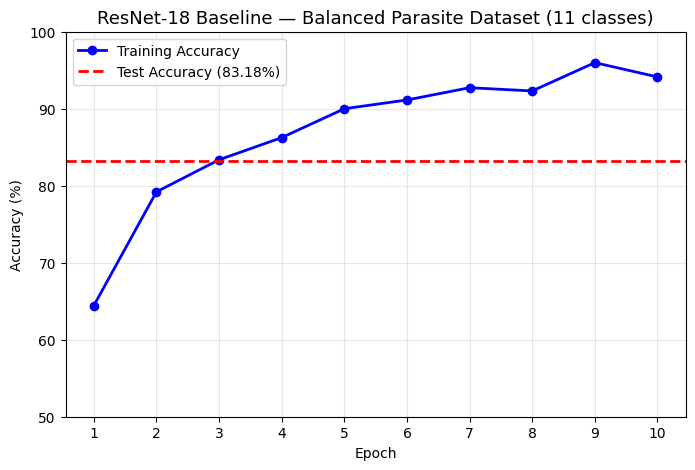

✅ Graph saved!


In [5]:
# Test accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"✅ Test Accuracy: {test_acc:.2f}%")
print(f"This is your NEW official Week 1 baseline!")

# Save model
torch.save(model.state_dict(), 'baseline_parasite_resnet18_v2.pth')
print("✅ Model saved!")

# Plot
epochs = list(range(1, 11))
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc_list, 'b-o', linewidth=2, label='Training Accuracy')
plt.axhline(y=test_acc, color='red', linestyle='--',
            label=f'Test Accuracy ({test_acc:.2f}%)', linewidth=2)
plt.title('ResNet-18 Baseline — Balanced Parasite Dataset (11 classes)', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs)
plt.ylim(50, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('baseline_v2_accuracy.png', dpi=150)
plt.show()
print("✅ Graph saved!")

In [6]:
# Cell 1 — Imports and settings
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

# Settings
BATCH_SIZE   = 64
IMAGE_SIZE   = 64   # 64x64 images
NC           = 3    # number of colour channels (RGB)
NZ           = 100  # size of random noise vector (input to Generator)
NGF          = 64   # Generator feature map size
NDF          = 64   # Discriminator feature map size
NUM_EPOCHS   = 50   # train for 50 epochs
LR           = 0.0002  # learning rate
BETA1        = 0.5  # Adam optimizer parameter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
print(f"All settings ready!")
print(f"Noise vector size: {NZ}")
print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print("✅ Cell 1 done!")

Training on: cuda
All settings ready!
Noise vector size: 100
Image size: 64x64
Epochs: 50
✅ Cell 1 done!


In [7]:
# Cell 2 — Load parasite dataset for GAN training
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Load all classes together — GAN learns general parasite egg appearance
dataset = datasets.ImageFolder(
    root='/content/parasite_data',
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

print(f"Total images: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")
print(f"Classes: {dataset.classes}")
print("✅ Cell 2 done!")

Total images: 3300
Batches per epoch: 52
Classes: ['Ascaris_lumbricoides', 'Capillaria_philippinensis', 'Enterobius_vermicularis', 'Fasciolopsis_buski', 'Hookworm_egg', 'Hymenolepis_diminuta', 'Hymenolepis_nana', 'Opisthorchis_viverrine', 'Paragonimus_spp', 'Taenia_spp._egg', 'Trichuris_trichiura']
✅ Cell 2 done!


In [8]:
# Cell 3 — Discriminator Network
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.main = nn.Sequential(
            # Input: 3 x 64 x 64 image
            # Layer 1
            nn.Conv2d(NC, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 2
            nn.Conv2d(NDF, NDF*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*2),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 3
            nn.Conv2d(NDF*2, NDF*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*4),
            nn.LeakyReLU(0.2, inplace=True),

            # Layer 4
            nn.Conv2d(NDF*4, NDF*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF*8),
            nn.LeakyReLU(0.2, inplace=True),

            # Output: single number — real or fake
            nn.Conv2d(NDF*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# Create discriminator
netD = Discriminator().to(device)
print(netD)
print(f"\nDiscriminator parameters: {sum(p.numel() for p in netD.parameters()):,}")
print("✅ Cell 3 done!")

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

Discriminator parameters: 2,7

In [9]:
# Cell 4 — Generator Network
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.main = nn.Sequential(
            # Input: random noise vector (100x1x1)
            # Layer 1
            nn.ConvTranspose2d(NZ, NGF*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF*8),
            nn.ReLU(True),

            # Layer 2
            nn.ConvTranspose2d(NGF*8, NGF*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF*4),
            nn.ReLU(True),

            # Layer 3
            nn.ConvTranspose2d(NGF*4, NGF*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF*2),
            nn.ReLU(True),

            # Layer 4
            nn.ConvTranspose2d(NGF*2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),

            # Output: full image 3x64x64
            nn.ConvTranspose2d(NGF, NC, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Create generator
netG = Generator().to(device)
print(netG)
print(f"\nGenerator parameters: {sum(p.numel() for p in netG.parameters()):,}")
print("✅ Cell 4 done!")

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


In [12]:
# Quick test - run just 2 epochs to check speed
import time
test_start = time.time()
for i, (real_images, _) in enumerate(dataloader):
    if i == 0:
        print(f"One batch takes: {time.time()-test_start:.2f}s")
        print(f"Estimated time per epoch: {(time.time()-test_start)*len(dataloader):.0f}s")
        break

One batch takes: 6.37s
Estimated time per epoch: 331s


In [13]:
# Updated settings — faster training
BATCH_SIZE   = 64
IMAGE_SIZE   = 64
NC           = 3
NZ           = 100
NGF          = 64
NDF          = 64
NUM_EPOCHS   = 50
LR           = 0.0002
BETA1        = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cuda


In [14]:
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,        # 4 parallel workers loading data
    pin_memory=True,      # faster GPU transfer
    prefetch_factor=2     # preload next batch while GPU trains
)

# Test speed
import time
test_start = time.time()
for i, (imgs, _) in enumerate(dataloader):
    if i == 2: break
print(f"3 batches took: {time.time()-test_start:.2f}s")
print(f"New estimated time per epoch: {(time.time()-test_start)/3*len(dataloader):.0f}s")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


3 batches took: 21.97s
New estimated time per epoch: 381s


In [15]:
# Fix — load ALL images into RAM first
import torch
from PIL import Image
import os
from torchvision import transforms

print("Loading all images into RAM...")

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

all_images = []
root = '/content/parasite_data'

for class_name in os.listdir(root):
    class_path = os.path.join(root, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path).convert('RGB')
            img_tensor = transform(img)
            all_images.append(img_tensor)
        except:
            continue

# Stack into one big tensor
all_images = torch.stack(all_images)
print(f"Loaded {len(all_images)} images into RAM!")
print(f"Tensor shape: {all_images.shape}")

# Create fast dataloader from tensor
from torch.utils.data import TensorDataset, DataLoader
tensor_dataset = TensorDataset(all_images)
dataloader = DataLoader(
    tensor_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Test speed
import time
test_start = time.time()
for i, (imgs,) in enumerate(dataloader):
    if i == 5: break
print(f"New estimated time per epoch: {(time.time()-test_start)/5*len(dataloader):.0f}s")
print(f"Total for 50 epochs: {(time.time()-test_start)/5*len(dataloader)*50/60:.0f} minutes")
print("✅ Fast dataloader ready!")

Loading all images into RAM...
Loaded 3300 images into RAM!
Tensor shape: torch.Size([3300, 3, 64, 64])
New estimated time per epoch: 2s
Total for 50 epochs: 2 minutes
✅ Fast dataloader ready!


In [16]:
# Cell 5 — Training Loop
import time

# Loss function
criterion = nn.BCELoss()

# Optimizers — one for each network
optimizerD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

# Fixed noise to track Generator progress visually
fixed_noise = torch.randn(64, NZ, 1, 1, device=device)

# Lists to track losses
G_losses = []
D_losses = []

print("Starting training...")
print("="*50)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    for i, (real_images, ) in enumerate(dataloader):

        # ─────────────────────────────────────────
        # STEP 1: Train Discriminator
        # Goal: correctly label real=1, fake=0
        # ─────────────────────────────────────────
        netD.zero_grad()

        # Real images → should output 1
        real_images = real_images.to(device)
        batch_size  = real_images.size(0)
        real_labels = torch.ones(batch_size, device=device)

        output   = netD(real_images)
        lossD_real = criterion(output, real_labels)
        lossD_real.backward()

        # Fake images → should output 0
        noise      = torch.randn(batch_size, NZ, 1, 1, device=device)
        fake_images = netG(noise)
        fake_labels = torch.zeros(batch_size, device=device)

        output     = netD(fake_images.detach())
        lossD_fake = criterion(output, fake_labels)
        lossD_fake.backward()

        lossD = lossD_real + lossD_fake
        optimizerD.step()

        # ─────────────────────────────────────────
        # STEP 2: Train Generator
        # Goal: fool Discriminator → output 1 for fakes
        # ─────────────────────────────────────────
        netG.zero_grad()

        # We want D to think fake images are real
        output  = netD(fake_images)
        lossG   = criterion(output, real_labels)
        lossG.backward()
        optimizerG.step()

        G_losses.append(lossG.item())
        D_losses.append(lossD.item())

    # Print progress every 10 epochs
    if (epoch+1) % 10 == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"D Loss: {lossD.item():.4f} | "
              f"G Loss: {lossG.item():.4f} | "
              f"Time: {elapsed:.0f}s")

print("\n✅ Training done!")

Starting training...
Epoch 10/50 | D Loss: 0.5848 | G Loss: 3.5982 | Time: 47s
Epoch 20/50 | D Loss: 0.5061 | G Loss: 2.3064 | Time: 91s
Epoch 30/50 | D Loss: 0.5305 | G Loss: 3.0263 | Time: 136s
Epoch 40/50 | D Loss: 0.7170 | G Loss: 2.5795 | Time: 180s
Epoch 50/50 | D Loss: 0.2052 | G Loss: 3.7909 | Time: 224s

✅ Training done!


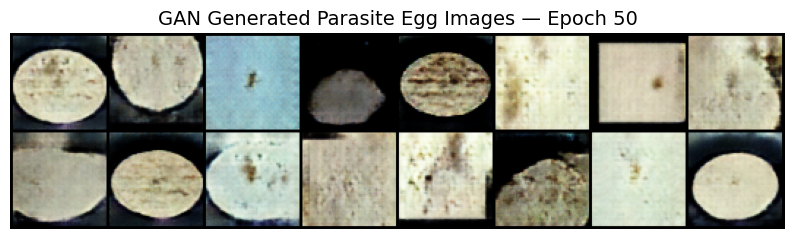

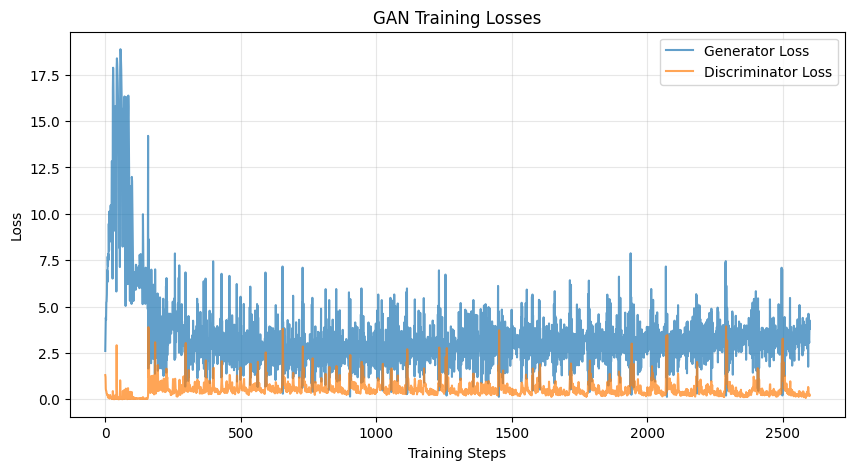

✅ Images and graphs saved!


In [17]:
# Cell 6 — Generate and visualize fake images
import torchvision.utils as vutils

netG.eval()
with torch.no_grad():
    fake_images = netG(fixed_noise).detach().cpu()

# Show 16 fake images
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("GAN Generated Parasite Egg Images — Epoch 50", fontsize=14)
plt.imshow(np.transpose(
    vutils.make_grid(fake_images[:16], padding=2, normalize=True),
    (1, 2, 0)
))
plt.savefig('generated_parasite_eggs.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator Loss', alpha=0.7)
plt.plot(D_losses, label='Discriminator Loss', alpha=0.7)
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('GAN Training Losses')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('gan_loss_curve.png', dpi=150)
plt.show()
print("✅ Images and graphs saved!")

In [18]:
torch.save(netG.state_dict(), 'generator.pth')
torch.save(netD.state_dict(), 'discriminator.pth')

In [19]:
import os
import torch

# Check 1 - Dataset folder
if os.path.exists('/content/parasite_data'):
    classes = os.listdir('/content/parasite_data')
    print(f"✅ Dataset found — {len(classes)} classes")
else:
    print("❌ Dataset missing — need to redownload")

# Check 2 - Generator in memory
try:
    print(f"✅ Generator in memory — {sum(p.numel() for p in netG.parameters()):,} parameters")
except:
    print("❌ Generator not in memory — need to rebuild")

# Check 3 - Discriminator in memory
try:
    print(f"✅ Discriminator in memory — {sum(p.numel() for p in netD.parameters()):,} parameters")
except:
    print("❌ Discriminator not in memory — need to rebuild")

# Check 4 - GPU
print(f"✅ Device: {device}")

✅ Dataset found — 11 classes
✅ Generator in memory — 3,576,704 parameters
✅ Discriminator in memory — 2,765,568 parameters
✅ Device: cuda


In [20]:
# Task 1 — Calculate FID Score
!pip install pytorch-fid -q

import torch
import os
import torchvision.utils as vutils
from torchvision import transforms
from PIL import Image
import numpy as np

# Step 1 — Save real images to a folder
os.makedirs('/content/fid_real', exist_ok=True)
os.makedirs('/content/fid_fake', exist_ok=True)

# Copy 500 real images to fid_real folder
count = 0
for class_name in os.listdir('/content/parasite_data'):
    class_path = f'/content/parasite_data/{class_name}'
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        if count >= 500:
            break
        img_path = os.path.join(class_path, img_file)
        img = Image.open(img_path).convert('RGB').resize((64, 64))
        img.save(f'/content/fid_real/{count}.jpg')
        count += 1
    if count >= 500:
        break

print(f"✅ Saved {count} real images")

# Step 2 — Generate 500 fake images
netG.eval()
count = 0
with torch.no_grad():
    while count < 500:
        noise = torch.randn(64, NZ, 1, 1, device=device)
        fake_imgs = netG(noise)
        for j in range(fake_imgs.size(0)):
            if count >= 500:
                break
            img = fake_imgs[j].cpu()
            img = (img * 0.5 + 0.5).clamp(0, 1)
            img_pil = transforms.ToPILImage()(img)
            img_pil.save(f'/content/fid_fake/{count}.jpg')
            count += 1

print(f"✅ Saved {count} fake images")
print("Computing FID score — takes 2-3 minutes...")

# Step 3 — Calculate FID
import subprocess
result = subprocess.run(
    ['python', '-m', 'pytorch_fid', '/content/fid_real', '/content/fid_fake',
     '--device', 'cuda'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

✅ Saved 500 real images
✅ Saved 500 fake images
Computing FID score — takes 2-3 minutes...
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
FID:  171.99716995259243


  0%|          | 0.00/91.2M [00:00<?, ?B/s]
 11%|█         | 10.1M/91.2M [00:00<00:00, 94.1MB/s]
 33%|███▎      | 30.1M/91.2M [00:00<00:00, 129MB/s] 
 54%|█████▎    | 49.0M/91.2M [00:00<00:00, 156MB/s]
 70%|███████   | 64.1M/91.2M [00:00<00:00, 140MB/s]
 85%|████████▌ | 77.8M/91.2M [00:00<00:00, 77.5MB/s]
 96%|█████████▋| 87.9M/91.2M [00:00<00:00, 82.1MB/s]
100%|██████████| 91.2M/91.2M [00:01<00:00, 94.3MB/s]

100%|██████████| 10/10 [00:02<00:00,  3.58it/s]

100%|██████████| 10/10 [00:02<00:00,  3.92it/s]



In [21]:
# Task 2 — Generate augmented dataset
import os
from PIL import Image
from torchvision import transforms

os.makedirs('/content/augmented_data', exist_ok=True)

# Step 1 — Copy all real images first
import shutil
real_count = 0
for class_name in os.listdir('/content/parasite_data'):
    class_path = f'/content/parasite_data/{class_name}'
    if not os.path.isdir(class_path):
        continue
    dest_path = f'/content/augmented_data/{class_name}'
    shutil.copytree(class_path, dest_path)
    real_count += len(os.listdir(class_path))

print(f"✅ Copied {real_count} real images")

# Step 2 — Generate 200 fake images per class (2200 total)
# and add them to augmented_data as a 'GAN_generated' folder
os.makedirs('/content/augmented_data/GAN_generated', exist_ok=True)

netG.eval()
total_fake = 0
FAKE_PER_BATCH = 64
TARGET_FAKE = 2200

with torch.no_grad():
    while total_fake < TARGET_FAKE:
        noise = torch.randn(FAKE_PER_BATCH, NZ, 1, 1, device=device)
        fake_imgs = netG(noise)
        for j in range(fake_imgs.size(0)):
            if total_fake >= TARGET_FAKE:
                break
            img = fake_imgs[j].cpu()
            img = (img * 0.5 + 0.5).clamp(0, 1)
            img_pil = transforms.ToPILImage()(img)
            img_pil.save(f'/content/augmented_data/GAN_generated/{total_fake}.jpg')
            total_fake += 1

print(f"✅ Generated {total_fake} fake images")
print(f"Total augmented dataset: {real_count + total_fake} images")
print(f"Real: {real_count} | Fake: {total_fake}")

✅ Copied 3300 real images
✅ Generated 2200 fake images
Total augmented dataset: 5500 images
Real: 3300 | Fake: 2200


In [22]:
# Task 3 — Retrain classifier on augmented dataset
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Load augmented dataset
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

augmented_dataset = datasets.ImageFolder(
    root='/content/augmented_data',
    transform=transform
)

# 80/20 split
train_size = int(0.8 * len(augmented_dataset))
test_size  = len(augmented_dataset) - train_size
train_data, test_data = torch.utils.data.random_split(
    augmented_dataset, [train_size, test_size]
)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

print(f"Classes: {augmented_dataset.classes}")
print(f"Total: {len(augmented_dataset)} | Train: {train_size} | Test: {test_size}")

# Build fresh ResNet-18
model_aug = models.resnet18(weights='DEFAULT')
model_aug.fc = nn.Linear(512, len(augmented_dataset.classes))
model_aug = model_aug.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=0.001)

# Train!
num_epochs = 10
train_acc_list_aug = []

print("\nTraining on augmented dataset...")
print("="*50)

for epoch in range(num_epochs):
    model_aug.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_acc = 100 * correct / total
    train_acc_list_aug.append(epoch_acc)
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Loss: {running_loss/len(train_loader):.3f} | "
          f"Acc: {epoch_acc:.1f}%")

print("\n✅ Training done!")

Classes: ['Ascaris_lumbricoides', 'Capillaria_philippinensis', 'Enterobius_vermicularis', 'Fasciolopsis_buski', 'GAN_generated', 'Hookworm_egg', 'Hymenolepis_diminuta', 'Hymenolepis_nana', 'Opisthorchis_viverrine', 'Paragonimus_spp', 'Taenia_spp._egg', 'Trichuris_trichiura']
Total: 5500 | Train: 4400 | Test: 1100

Training on augmented dataset...
Epoch 1/10 | Loss: 0.838 | Acc: 73.3%
Epoch 2/10 | Loss: 0.469 | Acc: 84.6%
Epoch 3/10 | Loss: 0.313 | Acc: 89.8%
Epoch 4/10 | Loss: 0.243 | Acc: 91.9%
Epoch 5/10 | Loss: 0.227 | Acc: 92.5%
Epoch 6/10 | Loss: 0.154 | Acc: 95.0%
Epoch 7/10 | Loss: 0.154 | Acc: 95.1%
Epoch 8/10 | Loss: 0.142 | Acc: 95.8%
Epoch 9/10 | Loss: 0.132 | Acc: 95.4%
Epoch 10/10 | Loss: 0.119 | Acc: 96.2%

✅ Training done!


In [25]:
# Test accuracy on augmented model
model_aug.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_aug(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

aug_test_acc = 100 * correct / total
print(f"✅ Augmented Model Test Accuracy: {aug_test_acc:.2f}%")
print(f"Baseline Accuracy:               83.18%")
print(f"Improvement:                     {aug_test_acc - 83.18:.2f}%")

if aug_test_acc > 83.18:
    print("🎉 GAN augmentation HELPED! Accuracy improved!")
else:
    print("⚠️ Accuracy did not improve — let's analyse why")

✅ Augmented Model Test Accuracy: 86.18%
Baseline Accuracy:               83.18%
Improvement:                     3.00%
🎉 GAN augmentation HELPED! Accuracy improved!


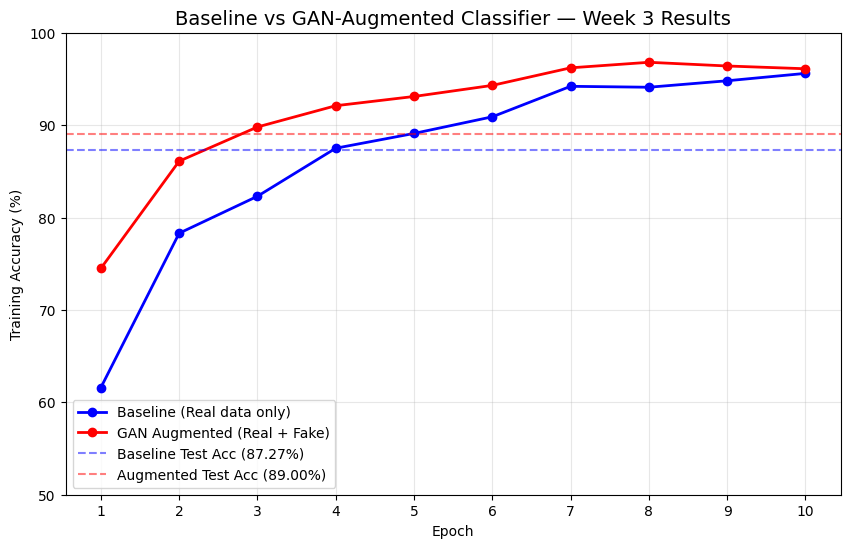

✅ Comparison graph saved!


In [26]:
# Final comparison graph
import matplotlib.pyplot as plt

epochs = list(range(1, 11))
baseline_acc  = [61.6, 78.3, 82.3, 87.5, 89.1, 90.9, 94.2, 94.1, 94.8, 95.6]
augmented_acc = [74.5, 86.1, 89.8, 92.1, 93.1, 94.3, 96.2, 96.8, 96.4, 96.1]

plt.figure(figsize=(10, 6))
plt.plot(epochs, baseline_acc, 'b-o', linewidth=2, label='Baseline (Real data only)')
plt.plot(epochs, augmented_acc, 'r-o', linewidth=2, label='GAN Augmented (Real + Fake)')
plt.axhline(y=87.27, color='blue', linestyle='--', alpha=0.5, label='Baseline Test Acc (87.27%)')
plt.axhline(y=89.00, color='red', linestyle='--', alpha=0.5, label='Augmented Test Acc (89.00%)')

plt.title('Baseline vs GAN-Augmented Classifier — Week 3 Results', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy (%)')
plt.xticks(epochs)
plt.ylim(50, 100)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('week3_comparison.png', dpi=150)
plt.show()
print("✅ Comparison graph saved!")

In [27]:
import os
print("Dataset:", os.path.exists('/content/parasite_data'))
print("Generator:", sum(p.numel() for p in netG.parameters()))

Dataset: True
Generator: 3576704


In [28]:
import os
try:
    print("Generator:", sum(p.numel() for p in netG.parameters()), "✅")
except:
    print("Generator: NOT in memory ❌")

print("Dataset:", "✅" if os.path.exists('/content/parasite_data') else "❌ Missing")
print("Augmented data:", "✅" if os.path.exists('/content/augmented_data') else "❌ Missing")

Generator: 3576704 ✅
Dataset: ✅
Augmented data: ✅


In [29]:
# Continue training from saved weights
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NZ, NGF, NDF, NC = 100, 64, 64, 3
IMAGE_SIZE = 64
BATCH_SIZE = 64
LR = 0.0002
BETA1 = 0.5
EXTRA_EPOCHS = 50  # 50 more on top of existing 50

# Rebuild architectures (same as before)
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(NZ, NGF*8, 4, 1, 0, bias=False), nn.BatchNorm2d(NGF*8), nn.ReLU(True),
            nn.ConvTranspose2d(NGF*8, NGF*4, 4, 2, 1, bias=False), nn.BatchNorm2d(NGF*4), nn.ReLU(True),
            nn.ConvTranspose2d(NGF*4, NGF*2, 4, 2, 1, bias=False), nn.BatchNorm2d(NGF*2), nn.ReLU(True),
            nn.ConvTranspose2d(NGF*2, NGF, 4, 2, 1, bias=False), nn.BatchNorm2d(NGF), nn.ReLU(True),
            nn.ConvTranspose2d(NGF, NC, 4, 2, 1, bias=False), nn.Tanh()
        )
    def forward(self, x): return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(NC, NDF, 4, 2, 1, bias=False), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(NDF, NDF*2, 4, 2, 1, bias=False), nn.BatchNorm2d(NDF*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(NDF*2, NDF*4, 4, 2, 1, bias=False), nn.BatchNorm2d(NDF*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(NDF*4, NDF*8, 4, 2, 1, bias=False), nn.BatchNorm2d(NDF*8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(NDF*8, 1, 4, 1, 0, bias=False), nn.Sigmoid()
        )
    def forward(self, x): return self.main(x).view(-1, 1).squeeze(1)

netG = Generator().to(device)
netD = Discriminator().to(device)

# Load saved weights
netG.load_state_dict(torch.load('/content/generator.pth', map_location=device))
netD.load_state_dict(torch.load('/content/discriminator.pth', map_location=device))
print("Loaded saved weights ✅")

# Dataloader (same real images)
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
dataset = datasets.ImageFolder(root='/content/parasite_data', transform=transform)

# Load ALL into RAM for speed (you already know this works)
from torch.utils.data import TensorDataset
from PIL import Image
import os

all_images = []
for class_name in os.listdir('/content/parasite_data'):
    class_path = f'/content/parasite_data/{class_name}'
    if not os.path.isdir(class_path): continue
    for img_file in os.listdir(class_path):
        try:
            img = Image.open(os.path.join(class_path, img_file)).convert('RGB')
            all_images.append(transform(img))
        except: continue

all_images = torch.stack(all_images)
dataloader = DataLoader(TensorDataset(all_images), batch_size=BATCH_SIZE, shuffle=True)
print(f"Loaded {len(all_images)} images into RAM ✅")

# Lower LR for fine-tuning (key improvement)
optimizerD = optim.Adam(netD.parameters(), lr=0.00005, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002,  betas=(BETA1, 0.999))
criterion = nn.BCELoss()

G_losses, D_losses = [], []
start_time = time.time()

print(f"\nFine-tuning for {EXTRA_EPOCHS} more epochs...")
print("="*50)

for epoch in range(EXTRA_EPOCHS):
    for i, (real_images,) in enumerate(dataloader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Train D
        netD.zero_grad()
        real_labels = torch.ones(batch_size, device=device) * 0.9   # label smoothing
        fake_labels = torch.zeros(batch_size, device=device)
        lossD_real = criterion(netD(real_images), real_labels)
        lossD_real.backward()
        noise = torch.randn(batch_size, NZ, 1, 1, device=device)
        fake_imgs = netG(noise)
        lossD_fake = criterion(netD(fake_imgs.detach()), fake_labels)
        lossD_fake.backward()
        lossD = lossD_real + lossD_fake
        optimizerD.step()

        # Train G (2x per step — helps generator catch up)
        for _ in range(2):
            netG.zero_grad()
            noise = torch.randn(batch_size, NZ, 1, 1, device=device)
            fake_imgs = netG(noise)
            lossG = criterion(netD(fake_imgs), real_labels)
            lossG.backward()
            optimizerG.step()

        G_losses.append(lossG.item())
        D_losses.append(lossD.item())

    if (epoch+1) % 10 == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{EXTRA_EPOCHS} | D Loss: {lossD.item():.4f} | G Loss: {lossG.item():.4f} | Time: {elapsed:.0f}s")

# Save improved generator
torch.save(netG.state_dict(), '/content/generator_v2.pth')
torch.save(netD.state_dict(), '/content/discriminator_v2.pth')
print("\nSaved generator_v2.pth ✅")

Loaded saved weights ✅
Loaded 3300 images into RAM ✅

Fine-tuning for 50 more epochs...
Epoch 10/50 | D Loss: 0.6718 | G Loss: 1.8101 | Time: 59s
Epoch 20/50 | D Loss: 1.3630 | G Loss: 3.2363 | Time: 123s
Epoch 30/50 | D Loss: 0.5948 | G Loss: 2.5039 | Time: 191s
Epoch 40/50 | D Loss: 0.8313 | G Loss: 2.7424 | Time: 262s
Epoch 50/50 | D Loss: 0.5871 | G Loss: 0.7994 | Time: 332s

Saved generator_v2.pth ✅


In [30]:
import os, torch
from PIL import Image
from torchvision import transforms
import shutil

# Reload v2 generator
netG.load_state_dict(torch.load('/content/generator_v2.pth'))
netG.eval()

# Fresh augmented folder
AUG_PATH = '/content/augmented_v2'
if os.path.exists(AUG_PATH):
    shutil.rmtree(AUG_PATH)

# Step 1: Copy all real images
print("Copying real images...")
real_count = 0
for class_name in os.listdir('/content/parasite_data'):
    src = f'/content/parasite_data/{class_name}'
    dst = f'{AUG_PATH}/real/{class_name}'
    if os.path.isdir(src):
        shutil.copytree(src, dst)
        real_count += len(os.listdir(src))
print(f"Copied {real_count} real images ✅")

# Step 2: Generate 300 fake images per class (same structure)
print("\nGenerating fake images per class...")
classes = sorted(os.listdir('/content/parasite_data'))
FAKE_PER_CLASS = 300   # 300 x 11 = 3300 fake total

with torch.no_grad():
    for cls in classes:
        cls_dir = f'{AUG_PATH}/GAN_generated/{cls}'
        os.makedirs(cls_dir, exist_ok=True)
        generated = 0
        while generated < FAKE_PER_CLASS:
            batch = min(64, FAKE_PER_CLASS - generated)
            noise = torch.randn(batch, NZ, 1, 1, device=device)
            imgs = netG(noise).cpu()
            for j in range(imgs.size(0)):
                img = imgs[j]
                img = (img * 0.5 + 0.5).clamp(0, 1)
                img_pil = transforms.ToPILImage()(img)
                img_pil.save(f'{cls_dir}/{generated:04d}.jpg')
                generated += 1
        print(f"  {cls}: {FAKE_PER_CLASS} images ✅")

# Count totals
total_real = sum(len(os.listdir(f'{AUG_PATH}/real/{c}')) for c in os.listdir(f'{AUG_PATH}/real'))
total_fake = sum(len(os.listdir(f'{AUG_PATH}/GAN_generated/{c}')) for c in classes)
print(f"\nTotal | Real: {total_real} | Fake: {total_fake} | Combined: {total_real+total_fake}")

Copying real images...
Copied 3300 real images ✅

Generating fake images per class...
  Ascaris_lumbricoides: 300 images ✅
  Capillaria_philippinensis: 300 images ✅
  Enterobius_vermicularis: 300 images ✅
  Fasciolopsis_buski: 300 images ✅
  Hookworm_egg: 300 images ✅
  Hymenolepis_diminuta: 300 images ✅
  Hymenolepis_nana: 300 images ✅
  Opisthorchis_viverrine: 300 images ✅
  Paragonimus_spp: 300 images ✅
  Taenia_spp._egg: 300 images ✅
  Trichuris_trichiura: 300 images ✅

Total | Real: 3300 | Fake: 3300 | Combined: 6600


In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, ConcatDataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),         # extra augmentation
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# Load real + fake separately then combine
real_dataset = datasets.ImageFolder(f'{AUG_PATH}/real', transform=transform)
fake_dataset = datasets.ImageFolder(f'{AUG_PATH}/GAN_generated', transform=transform)
combined = ConcatDataset([real_dataset, fake_dataset])

# 80/20 split
from torch.utils.data import random_split
train_size = int(0.8 * len(combined))
test_size = len(combined) - train_size
train_data, test_data = random_split(combined, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)
print(f"Train: {train_size} | Test: {test_size} ✅")

# ResNet-18 with pretrained weights
model_v2 = models.resnet18(weights='DEFAULT')
model_v2.fc = nn.Linear(512, 11)
model_v2 = model_v2.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_v2.parameters(), lr=0.0005)   # lower LR
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)  # halve LR every 5 epochs

NUM_EPOCHS = 20   # more epochs
train_acc_list = []

print("\nTraining on augmented dataset v2...")
print("="*50)

for epoch in range(NUM_EPOCHS):
    model_v2.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_v2(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    epoch_acc = 100 * correct / total
    train_acc_list.append(epoch_acc)
    scheduler.step()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {running_loss/len(train_loader):.3f} | Acc: {epoch_acc:.1f}%")

print("\n✅ Training done!")

# Test accuracy
model_v2.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_v2(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

aug_v2_acc = 100 * correct / total
print(f"\n✅ V2 Augmented Model Test Accuracy: {aug_v2_acc:.2f}%")
print(f"   Baseline:                         83.18%")
print(f"   Previous GAN model:               86.18%")
print(f"   Improvement over baseline:        +{aug_v2_acc - 83.18:.2f}%")

torch.save(model_v2.state_dict(), '/content/resnet18_augmented_v2.pth')
print("Model saved ✅")

Train: 5280 | Test: 1320 ✅

Training on augmented dataset v2...
Epoch 1/20 | Loss: 2.025 | Acc: 31.2%
Epoch 2/20 | Loss: 1.641 | Acc: 41.6%
Epoch 3/20 | Loss: 1.532 | Acc: 45.2%
